In [1]:
# from numba import njit, prange
import numpy as np
import faiss

data = np.load(f"../data/save/train_test_new-0-0-0-0.npz")

x = np.array(data["x"], dtype=np.float64)
y = np.array(data["y"], dtype=np.float64)
w = np.array(data["w"], dtype=np.float64)
coor = np.array(data["coor"], dtype=np.int64)

print(x.shape, y.shape, w.shape, coor.shape)

(414003, 108) (414003, 5) (414003,) (414003, 27, 3)


In [2]:
name_plot = "plot-b3lyp"

if name_plot == "plot-b3lyp":
    y = y[:, 0]
if name_plot == "plot-cc-b3lyp":
    y = y[:, 0] + y[:, 1] + y[:, 2] + y[:, 3]
if name_plot == "plot-cc":
    y = y[:, 1] + y[:, 2]
if name_plot == "plot-lda":
    y = y[:, 4]
# exc_over_dm_b3lyp_grids
# exc_over_dm_cc_2_grids
# exc_over_dm_cc_1_j_grids
# exc_over_dm_cc_1_k_grids

name_plot = f"{name_plot}-{x.shape[1]}"

In [3]:
(num_sample, dim_sample) = x.shape
res = faiss.StandardGpuResources()
flat_config = faiss.GpuIndexFlatConfig()
flat_config.device = 0
index = faiss.GpuIndexFlatL2(res, dim_sample, flat_config)
index.add(x)

In [4]:
b = x.copy()
distances, indices = index.search(b, 20)
name = data["name"]

distances = np.sqrt(distances) / x.shape[1]
var_y = np.var(np.einsum("ij,i->ij", y[indices], x[:, 0] * w), axis=1)
max_x = 1e-8

mean_of_distances = np.max(distances, axis=1)
mean_of_distances[mean_of_distances < max_x] = -1
mean_of_distances[mean_of_distances > max_x] = 0
mean_of_distances = -mean_of_distances

plot_number = 16
argsort_ = np.argsort(mean_of_distances * var_y)[::-1][:plot_number]

energy = np.einsum("ij,i->ij", y[indices[argsort_]], (x[:, 0] * w)[argsort_])
distances = distances[argsort_]
name = name[indices[argsort_]]
max_y = np.max(np.abs(energy - energy[:, [0]])) * 627.509
print(max_y)

3.7114496778660516e-06


In [5]:
# (sum_of_distances_reverse * var_y)[argsort_]
index_check = 10
print(
    np.sum(
        (x[indices[argsort_[index_check]]] - x[indices[argsort_[index_check]]][0]) ** 2,
        axis=1,
    )
)
print(np.max(distances[index_check]))
print(np.max(np.abs((energy[index_check] - energy[index_check][0]) * 627.509)))
print(name[index_check])

[0.00000000e+00 1.37904258e-13 1.54950971e-13 2.05853142e-13
 2.10470844e-13 2.60115607e-13 3.51282200e-13 3.91672731e-13
 4.12617275e-13 4.19546755e-13 4.27203855e-13 4.41116208e-13
 4.64580530e-13 4.80220908e-13 4.97162450e-13 5.04645936e-13
 5.18160404e-13 5.19513515e-13 5.50196126e-13 5.71760670e-13]
7.0013804e-09
1.0150715102098336e-06
['ethane_cc-pVDZ_0-1_1_-0.5000_6_32_94'
 'methane_cc-pVDZ_0-1_1_-0.4000_1_32_38'
 'methane_cc-pVDZ_0-1_1_-0.3500_1_32_166'
 'methane_cc-pVDZ_0-1_1_-0.4000_1_32_166'
 'methane_cc-pVDZ_0-1_1_-0.2500_4_33_126'
 'methane_cc-pVDZ_0-1_1_-0.2000_4_33_126'
 'methane_cc-pVDZ_0-1_1_-0.1000_0_33_174'
 'methane_cc-pVDZ_0-1_1_-0.3000_4_33_126'
 'methane_cc-pVDZ_0-1_1_-0.3500_1_32_38'
 'methane_cc-pVDZ_0-1_1_-0.0500_4_33_118'
 'methane_cc-pVDZ_0-1_1_0.0000_4_33_118'
 'methane_cc-pVDZ_0-1_1_-0.4500_1_32_38'
 'methane_cc-pVDZ_0-1_1_0.5000_1_32_94'
 'methane_cc-pVDZ_0-1_1_-0.1000_4_33_118'
 'methane_cc-pVDZ_0-1_1_0.4000_2_34_190'
 'methane_cc-pVDZ_0-1_1_0.3500_2_34_

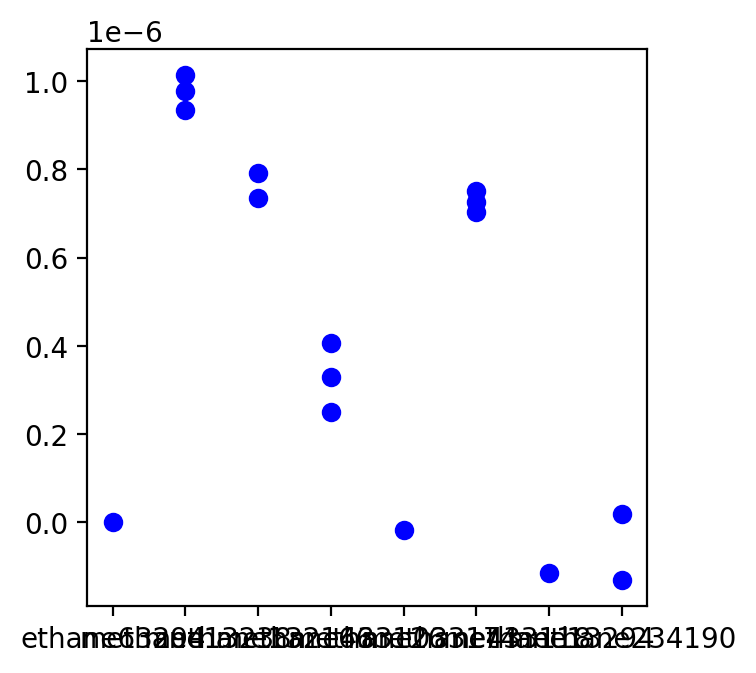

In [6]:
from matplotlib import pyplot as plt

plt.rcParams["figure.figsize"] = np.array([0.5, 0.5]) * 520 / 72
name_energy_dict = {}

for i in range(plot_number):
    name_energy_dict[name[index_check][i]] = (
        energy[index_check][i] - energy[index_check][0]
    ) * 627.509


name_dict = {
    "methane": 0,
    "ethane": 1,
    "ethylene": 2,
    "acetylene": 3,
}

x_name_dict = {}
x_energy_dict = {}

for name_i, energy_i in name_energy_dict.items():
    x_ = (
        name_i.split("_")[0]
        + name_i.split("_")[5]
        + name_i.split("_")[6]
        + name_i.split("_")[7]
    )
    if x_ in x_name_dict:
        x_name_dict[x_].append([name_i, energy_i])
    else:
        x_name_dict[x_] = [[name_i, energy_i]]
    plt.scatter(x_, energy_i, c="b")

In [7]:
from pathlib import Path

Path(f"{name_plot}-{max_x}/plot/").mkdir(parents=True, exist_ok=True)

for key_, value_ in x_name_dict.items():
    for j in value_:
        plt.scatter(float(j[0].split("_")[4]), j[1], c="r")
    plt.xticks(rotation=90)
    plt.xlabel(r"$\Delta$ x ($\AA$)")
    plt.ylabel("Energy (kcal/mol)")
    plt.xlim(-0.575, 0.575)
    plt.xticks(np.arange(-0.5, 0.6, 0.1))
    plt.savefig(f"{name_plot}-{max_x}/plot/{key_}_{len(value_)}.pdf", bbox_inches="tight")
    plt.savefig(f"{name_plot}-{max_x}/plot/{key_}_{len(value_)}.png", bbox_inches="tight", dpi=300)
    plt.close()
    print(key_, [i[0] for i in value_])

ethane63294 ['ethane_cc-pVDZ_0-1_1_-0.5000_6_32_94']
methane13238 ['methane_cc-pVDZ_0-1_1_-0.4000_1_32_38', 'methane_cc-pVDZ_0-1_1_-0.3500_1_32_38', 'methane_cc-pVDZ_0-1_1_-0.4500_1_32_38']
methane132166 ['methane_cc-pVDZ_0-1_1_-0.3500_1_32_166', 'methane_cc-pVDZ_0-1_1_-0.4000_1_32_166']
methane433126 ['methane_cc-pVDZ_0-1_1_-0.2500_4_33_126', 'methane_cc-pVDZ_0-1_1_-0.2000_4_33_126', 'methane_cc-pVDZ_0-1_1_-0.3000_4_33_126']
methane033174 ['methane_cc-pVDZ_0-1_1_-0.1000_0_33_174']
methane433118 ['methane_cc-pVDZ_0-1_1_-0.0500_4_33_118', 'methane_cc-pVDZ_0-1_1_0.0000_4_33_118', 'methane_cc-pVDZ_0-1_1_-0.1000_4_33_118']
methane13294 ['methane_cc-pVDZ_0-1_1_0.5000_1_32_94']
methane234190 ['methane_cc-pVDZ_0-1_1_0.4000_2_34_190', 'methane_cc-pVDZ_0-1_1_0.3500_2_34_190']


In [8]:
from matplotlib import pyplot as plt

color_dict = {
    "methane": "#004D40",
    "ethane": "#1A237E",
    "ethylene": "#212121",
    "acetylene": "#7B1FA2",
}

plt.rcParams["figure.figsize"] = np.array([0.5, 0.5]) * 520 / 72

f, axes = plt.subplots(1, 1)
axes = np.array(axes).reshape(1, 1)

begin_y = 0.125
end_y = 0.995
int_y = 0.0
begin_x = 0.175
end_x = 0.995
int_x = 0.0
end_x += int_x
end_y += int_y

shapexy = np.shape(axes)
inter_x = np.linspace(begin_x, end_x, shapexy[1] + 1)
inter_y = np.linspace(begin_y, end_y, shapexy[0] + 1)

delta_x = inter_x[1] - inter_x[0] - int_x
delta_y = inter_y[1] - inter_y[0] - int_y

for i in range(shapexy[0]):
    for j in range(shapexy[1]):
        axes[i][j].set_position(
            [
                inter_x[j],
                inter_y[i],
                inter_x[j + 1] - inter_x[j] - int_x,
                inter_y[i + 1] - inter_y[i] - int_y,
            ]
        )
        axes[i][j].xaxis.set_tick_params(
            direction="in", which="both", bottom=True, top=True
        )
        axes[i][j].yaxis.set_tick_params(
            direction="in", which="both", left=True, right=True
        )

        axes[i, j].set_xlim(-max_x * 0.1, max_x * 1.1)
        axes[i, j].set_ylim(-max_y * 1.1, max_y * 1.1)

        if i != 0:
            axes[i, j].set_xticks([])
        else:
            axes[i, j].set_xticks([0, max_x])
            axes[i, j].set_xticklabels([0, max_x])
        # if j != 0:
        #     axes[i][j].set_yticks([])
        # else:
        #     axes[i][j].set_yticks([-0.03, -0.02, -0.01, 0])
        #     axes[i][j].set_yticklabels([-0.03, -0.02, -0.01, 0])
        #     axes[i][j].set_yticks([0, 0.01, 0.02, 0.03])
        #     axes[i][j].set_yticklabels([0, 0.01, 0.02, 0.03])

for j in range(indices.shape[1]):
    axes[0, 0].scatter(
        distances[index_check][j],
        (energy[index_check][j] - energy[index_check][0]) * 627.509,
        c=(color_dict[name[index_check][j].split("_")[0]],),
    )

for i, c in color_dict.items():
    axes[0, 0].scatter([-1], [-1], c=c, label=i)

plt.xlabel("Distance of cube")
plt.ylabel(r"$\Delta$ Energy (kcal/mol)")
plt.legend()

plt.savefig(f"{name_plot}-{max_x}/sub_test.pdf", dpi=300, bbox_inches="tight")
plt.savefig(f"{name_plot}-{max_x}/sub_test.png", dpi=300, bbox_inches="tight")
plt.clf()

<Figure size 361.111x361.111 with 0 Axes>

In [9]:
from matplotlib import pyplot as plt

color_dict = {
    "methane": "#004D40",
    "ethane": "#1A237E",
    "ethylene": "#212121",
    "acetylene": "#7B1FA2",
}

plt.rcParams["figure.figsize"] = np.array([1.25, 1.25]) * 520 / 72

f, axes = plt.subplots(4, 4)
axes = axes.reshape(4, 4)

begin_y = 0.025
end_y = 0.95
int_y = 0.0
begin_x = 0.025
end_x = 0.95
int_x = 0.0
end_x += int_x
end_y += int_y

shapexy = np.shape(axes)
inter_x = np.linspace(begin_x, end_x, shapexy[1] + 1)
inter_y = np.linspace(begin_y, end_y, shapexy[0] + 1)

delta_x = inter_x[1] - inter_x[0] - int_x
delta_y = inter_y[1] - inter_y[0] - int_y

for i in range(shapexy[0]):
    for j in range(shapexy[1]):
        axes[i][j].set_position(
            [
                inter_x[j],
                inter_y[i],
                inter_x[j + 1] - inter_x[j] - int_x,
                inter_y[i + 1] - inter_y[i] - int_y,
            ]
        )
        axes[i][j].xaxis.set_tick_params(
            direction="in", which="both", bottom=True, top=True
        )
        axes[i][j].yaxis.set_tick_params(
            direction="in", which="both", left=True, right=True
        )

        axes[i, j].set_xlim(-max_x * 0.1, max_x * 1.1)
        # axes[i, j].set_ylim(-0.01, 0.11)
        axes[i, j].set_ylim(-max_y * 0.1, max_y * 1.1)

        if i != 0:
            axes[i, j].set_xticks([])
        else:
            axes[i, j].set_xticks([0, max_x])
            axes[i, j].set_xticklabels([0, max_x])
        if j != 0:
            axes[i][j].set_yticks([])
        # else:
        #     axes[i][j].set_yticks([0, 0.02])
        #     axes[i][j].set_yticklabels([0, 0.02])
        # axes[i][j].set_yticks([0, 0.01, 0.02, 0.03])
        # axes[i][j].set_yticklabels([0, 0.01, 0.02, 0.03])


for i in range(argsort_.shape[0]):
    axes_i, axes_j = np.unravel_index(i, (4, 4))
    for j in range(indices.shape[1]):
        axes[axes_i, axes_j].scatter(
            distances[i][j],
            np.abs(energy[i][j] - energy[i][0]) * 627.509,
            c=(color_dict[name[i][j].split("_")[0]],),
        )

    axes[axes_i, axes_j].text(
        0.01,
        1 - 0.01,
        f"{i}",
        transform=axes[axes_i, axes_j].transAxes,
        va="top",
    )
plt.savefig(f"{name_plot}-{max_x}/test.pdf", dpi=300, bbox_inches="tight")
plt.savefig(f"{name_plot}-{max_x}/test.png", dpi=300, bbox_inches="tight")
plt.clf()

<Figure size 902.778x902.778 with 0 Axes>